In [ ]:
import os, glob, warnings, logging
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from openslide import OpenSlide
from skimage.color import separate_stains, hed_from_rgb

warnings.filterwarnings('ignore')
logging.getLogger('PIL').setLevel(logging.ERROR)

DATA_ROOT = "/NAS145/liaolinbo/Data/MXB/6家医院各60张"

centers = ['301', '900', '云南肿瘤', '南京军总', '广西瑞康', '河南安阳']
labels = ['301', '900', 'YNZL', 'NJJZ', 'GXRK', 'HNAY']
colors = ['#A87B75', '#73889B', '#82937E', '#94839B', '#C19E77', '#9F8C7D']

plt.rcParams.update({
    'font.size': 11,
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.unicode_minus': False
})

bins = np.linspace(0.005, 0.12, 150)
bin_w = bins[1] - bins[0]
x = (bins[:-1] + bins[1:]) / 2
hist = {c: {'H': np.zeros(len(bins)-1), 'E': np.zeros(len(bins)-1)} for c in centers}

for c in centers:
    files = glob.glob(os.path.join(DATA_ROOT, c, "slides", "*.svs"))
    print(f"Processing {c}: {len(files)} slides")

    for f in tqdm(files):
        try:
            slide = OpenSlide(f)
            img = np.array(slide.get_thumbnail((1024, 1024)).convert('RGB'))
            slide.close()

            mask = (img[..., 0] < 235) & (img[..., 1] < 235) & (img[..., 2] < 235) & (img.mean(2) > 20)
            if not mask.any():
                continue

            hed = separate_stains(img, hed_from_rgb)
            for ch, idx in [('H', 0), ('E', 1)]:
                vals = hed[..., idx][mask]
                vals = vals[(vals >= bins[0]) & (vals <= bins[-1])]
                hist[c][ch] += np.histogram(vals, bins=bins)[0]

        except Exception:
            continue


fig, ax_h = plt.subplots(figsize=(7.5, 5.5), dpi=300, facecolor='white')
ax_e = ax_h.twiny()

for i, c in enumerate(centers):
    for ax, ch in [(ax_h, 'H'), (ax_e, 'E')]:
        h = hist[c][ch]
        if h.sum() == 0:
            continue
        dens = h / (h.sum() * bin_w)
        ax.plot(x, dens, color=colors[i], lw=2, alpha=0.88, label=labels[i] if ch == 'H' else None)
        ax.fill_between(x, 0, dens, color=colors[i], alpha=0.035)

ax_h.set_xlim(bins[0], bins[-1])
ax_e.set_xlim(bins[0], bins[-1])
ax_e.invert_xaxis()

ax_h.set_xlabel("◄ Hematoxylin (H) intensity", fontweight='bold')
ax_e.set_xlabel("Eosin (E) intensity ►", fontweight='bold')
ax_h.set_ylabel("Probability density")

ax_h.grid(axis='y', ls='--', color='#ECECEC', alpha=0.75)
ax_h.legend(loc='upper center', bbox_to_anchor=(0.5, 0.88), ncol=2,
            frameon=True, facecolor='white', edgecolor='#E5E5E5')

for ax in [ax_h, ax_e]:
    ax.spines['right'].set_visible(False)
ax_h.spines['top'].set_visible(False)
ax_e.spines['bottom'].set_visible(False)
ax_e.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig('./centers/domain_shift_density.svg', bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FS = 16
plt.rcParams.update({
    'font.size': FS,
    'axes.labelsize': FS,
    'xtick.labelsize': FS - 1,
    'ytick.labelsize': FS - 1,
    'legend.fontsize': FS - 2,
    'font.sans-serif': ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'sans-serif'],
    'axes.unicode_minus': False
})

df = pd.read_csv('Consistent/result.csv')

prob_cols = ['probs_301', 'probs_900', 'probs_云南肿瘤', 'probs_南京军总', 'probs_广西瑞康', 'probs_河南安阳']
pred_cols = ['pred_301', 'pred_900', 'pred_云南肿瘤', 'pred_南京军总', 'pred_广西瑞康', 'pred_河南安阳']
centers = ['301', '900', 'YNZL', 'NJJZ', 'GXRK', 'HNAY']

long_df = pd.concat([
    df[[p, 'label']].rename(columns={p: 'Probability', 'label': 'Label'}).assign(Center=c)
    for p, c in zip(prob_cols, centers)
], ignore_index=True)

long_df['Label'] = long_df['Label'].map({0: 'Benign', 1: 'Malignant'})

morandi = {'Benign': '#8DA399', 'Malignant': '#C48F86'}
C_TEXT, C_LINE, C_BG, C_EDGE = '#5B5E5C', '#B4B8B6', '#EAE7E2', '#CBD0CC'

sns.set_theme(style="whitegrid", rc={"grid.color": "#F0F0F0"})
fig, ax = plt.subplots(figsize=(12, 6.6), dpi=120)

sns.violinplot(
    data=long_df,
    x='Center',
    y='Probability',
    hue='Label',
    split=True,
    inner='box',
    palette=morandi,
    linewidth=1.2,
    width=0.75,
    ax=ax
)

ax.axhline(0.5, color=C_LINE, ls='--', lw=1.8, alpha=0.85, zorder=0)
ax.text(len(centers) - 0.55, 0.515, 'Threshold', fontsize=FS - 5, color=C_TEXT,
    va='bottom', ha='right', fontstyle='italic')

preds = df[pred_cols].values
full_agree = np.mean(np.all(preds == preds[:, :1], axis=1))
agree_56 = np.mean((preds.sum(axis=1) >= 5) | (preds.sum(axis=1) <= 1))

ax.text( 0.96, 0.94,
    f'Full agreement: {full_agree:.1%}\n≥5/6 agreement: {agree_56:.1%}',
    transform=ax.transAxes, ha='right', va='top', fontsize=FS - 3, fontweight='bold',
    color=C_TEXT,
    bbox=dict(
        boxstyle='round,pad=0.40',
        facecolor=C_BG,
        edgecolor=C_EDGE,
        linewidth=1.1,
        alpha=0.85
    )
)

ax.set_ylim(-0.04, 1.12)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'], color=C_TEXT)

ax.set_xlabel('')
ax.set_ylabel('Model Confidence', fontweight='semibold', color=C_TEXT)
ax.tick_params(axis='x', colors=C_TEXT)
ax.tick_params(axis='y', colors=C_TEXT)

leg = ax.legend(title='True Label', loc='upper left', frameon=True, title_fontsize=FS - 1)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_edgecolor(C_EDGE)
leg.get_title().set_color(C_TEXT)
for t in leg.get_texts():
    t.set_color(C_TEXT)

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
for s in ['left', 'bottom']:
    ax.spines[s].set_linewidth(1.3)
    ax.spines[s].set_color(C_EDGE)

os.makedirs('centers', exist_ok=True)
plt.tight_layout()
plt.savefig('centers/stain-robust.svg', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

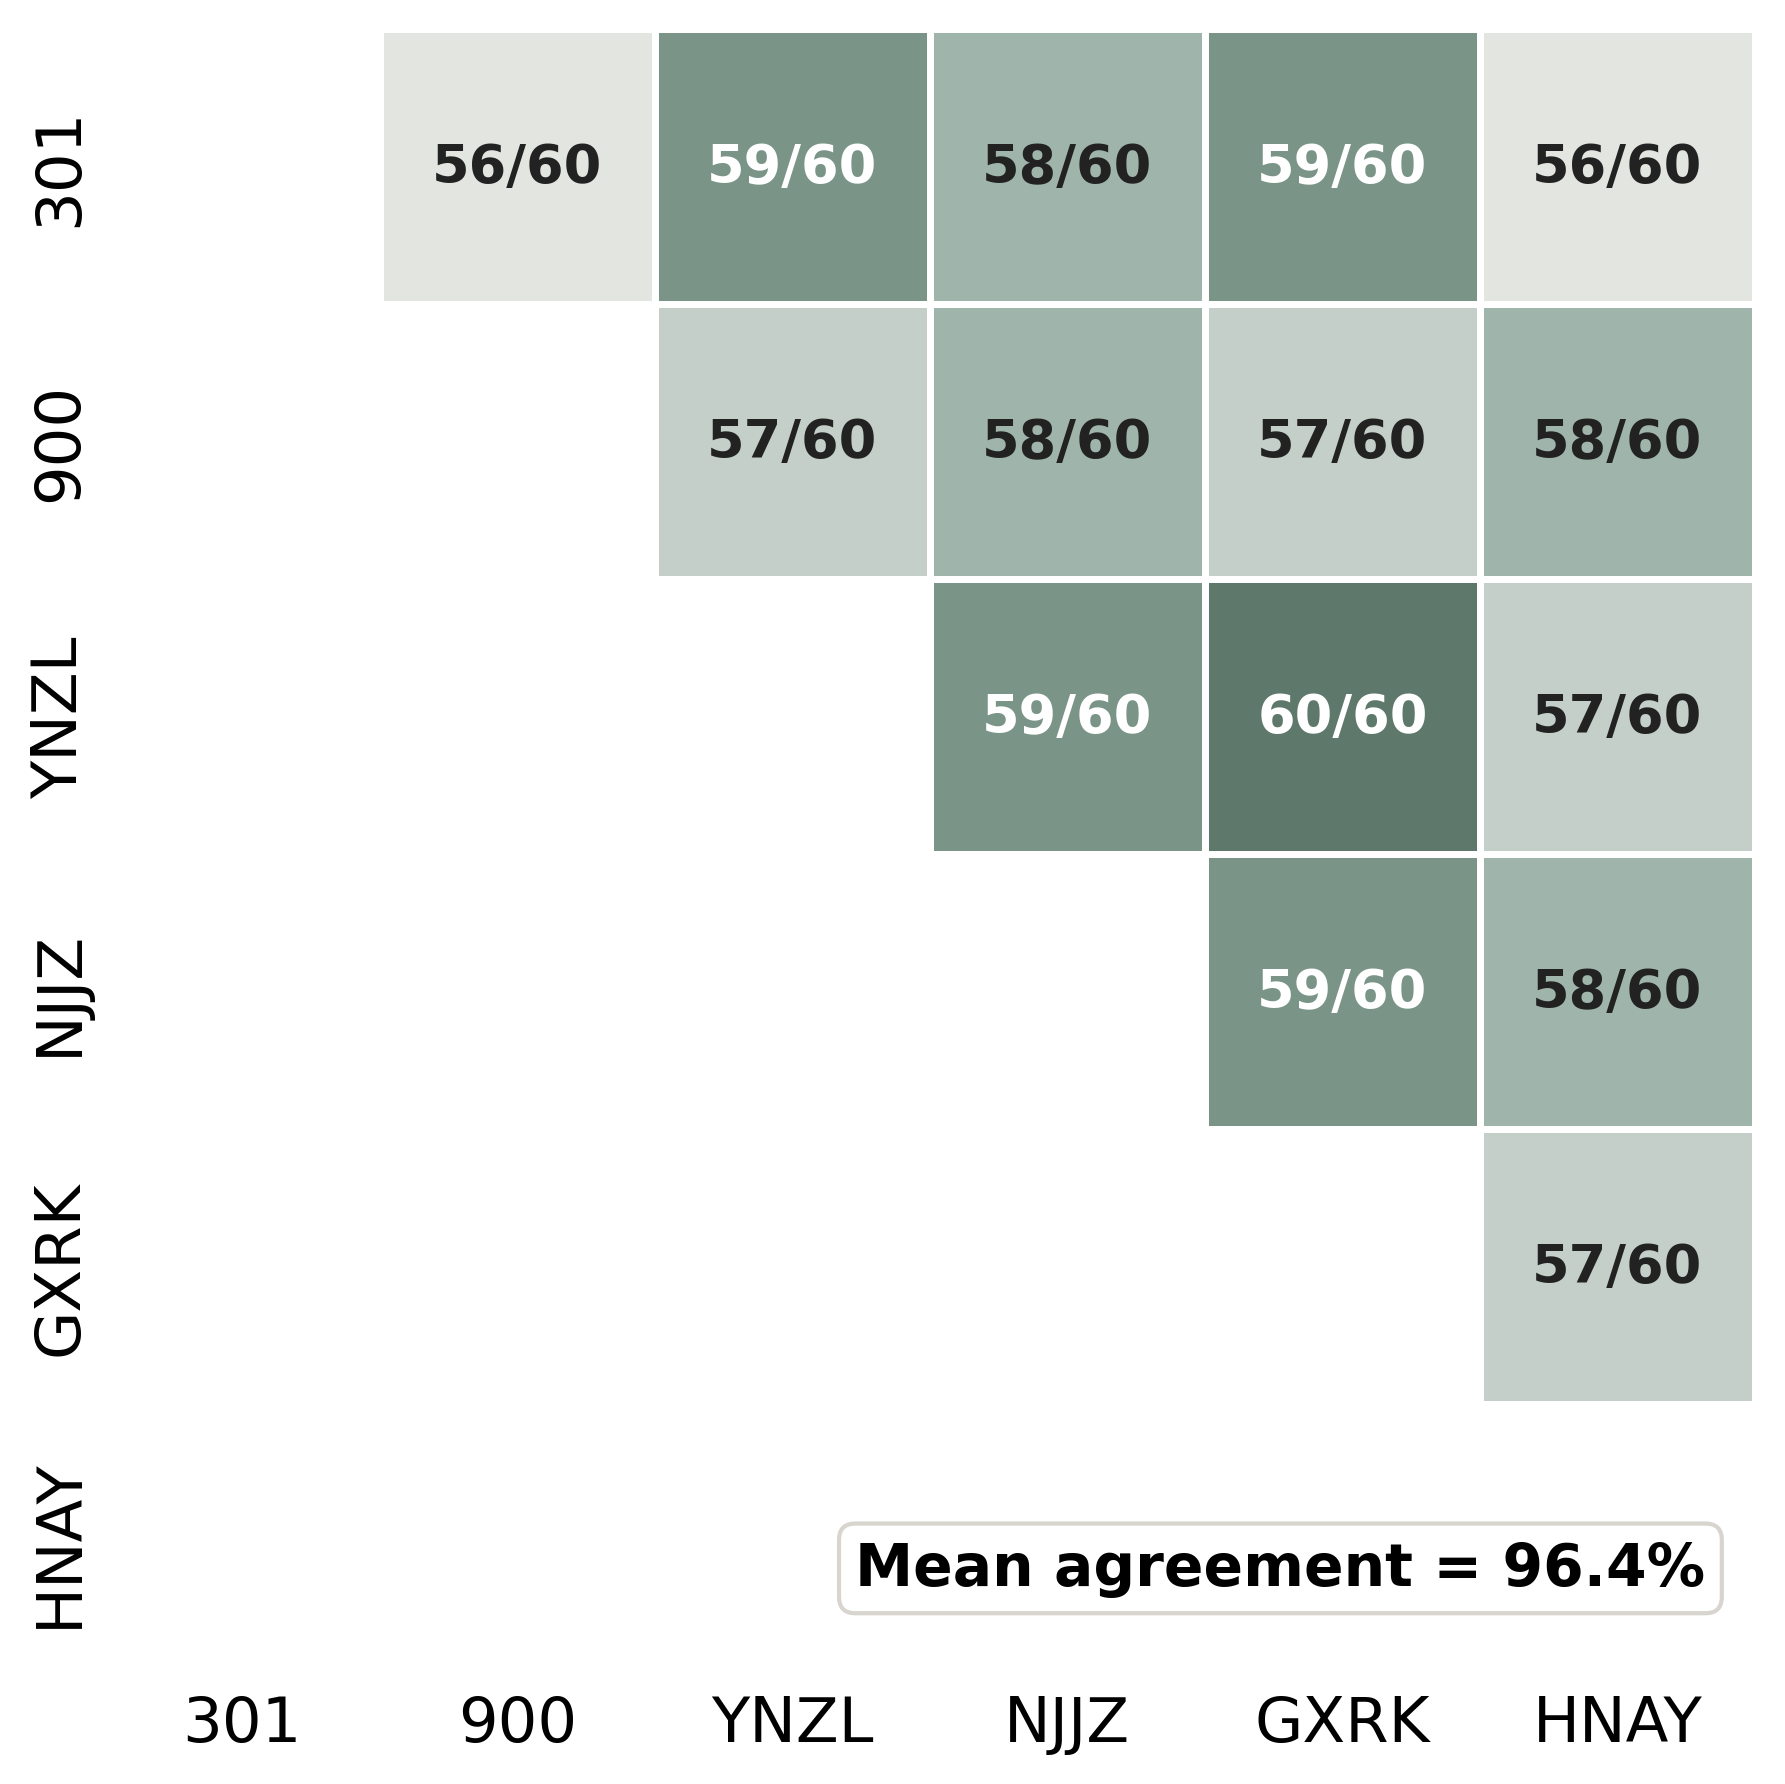

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Consistent/result.csv')

pred_cols = [
    'pred_301', 'pred_900', 'pred_云南肿瘤',
    'pred_南京军总', 'pred_广西瑞康', 'pred_河南安阳'
]
labels = ['301', '900', 'YNZL', 'NJJZ', 'GXRK', 'HNAY']

pred = df[pred_cols].values
n_centers, n_cases = len(labels), len(df)

agree_count = np.zeros((n_centers, n_centers), dtype=int)
agree_rate = np.zeros((n_centers, n_centers), dtype=float)

for i in range(n_centers):
    for j in range(n_centers):
        agree_count[i, j] = np.sum(pred[:, i] == pred[:, j])
        agree_rate[i, j] = agree_count[i, j] / n_cases

agree_df = pd.DataFrame(agree_rate * 100, index=labels, columns=labels)
annot_df = pd.DataFrame(
    [[f'{agree_count[i, j]}/{n_cases}' for j in range(n_centers)] for i in range(n_centers)],
    index=labels,
    columns=labels
)

mask = np.tril(np.ones_like(agree_df, dtype=bool))
vals = agree_rate[np.triu_indices_from(agree_rate, k=1)]
mean_agree = vals.mean()

plt.rcParams.update({
    'font.size': 15,
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.unicode_minus': False
})

cmap = sns.blend_palette(
    ['#F7F4EF', '#D8DDD8', '#AFC1B8', '#7F9A8E', '#5F786C'],
    as_cmap=True
)

fig, ax = plt.subplots(figsize=(7.2, 6.2), dpi=300, facecolor='white')

sns.heatmap(
    agree_df,
    mask=mask,
    cmap=cmap,
    vmin=92,
    vmax=100,
    annot=annot_df,
    fmt='',
    square=True,
    linewidths=1.6,
    linecolor='white',
    cbar=False,
    annot_kws={'fontsize': 13, 'fontweight': 'bold'},
    ax=ax
)

ax.text(
    0.97, 0.05,
    f'Mean agreement = {mean_agree:.1%}',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=14,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.28', facecolor='white', edgecolor='#D6D2CC', alpha=0.95)
)

for text in ax.texts:
    value = text.get_text()
    if '/' in value:
        num = int(value.split('/')[0])
        text.set_color('white' if num >= n_cases - 1 else '#222222')

ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', length=0, labelsize=15)

os.makedirs('centers', exist_ok=True)
plt.tight_layout()
plt.savefig('centers/prediction_agreement_matrix.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

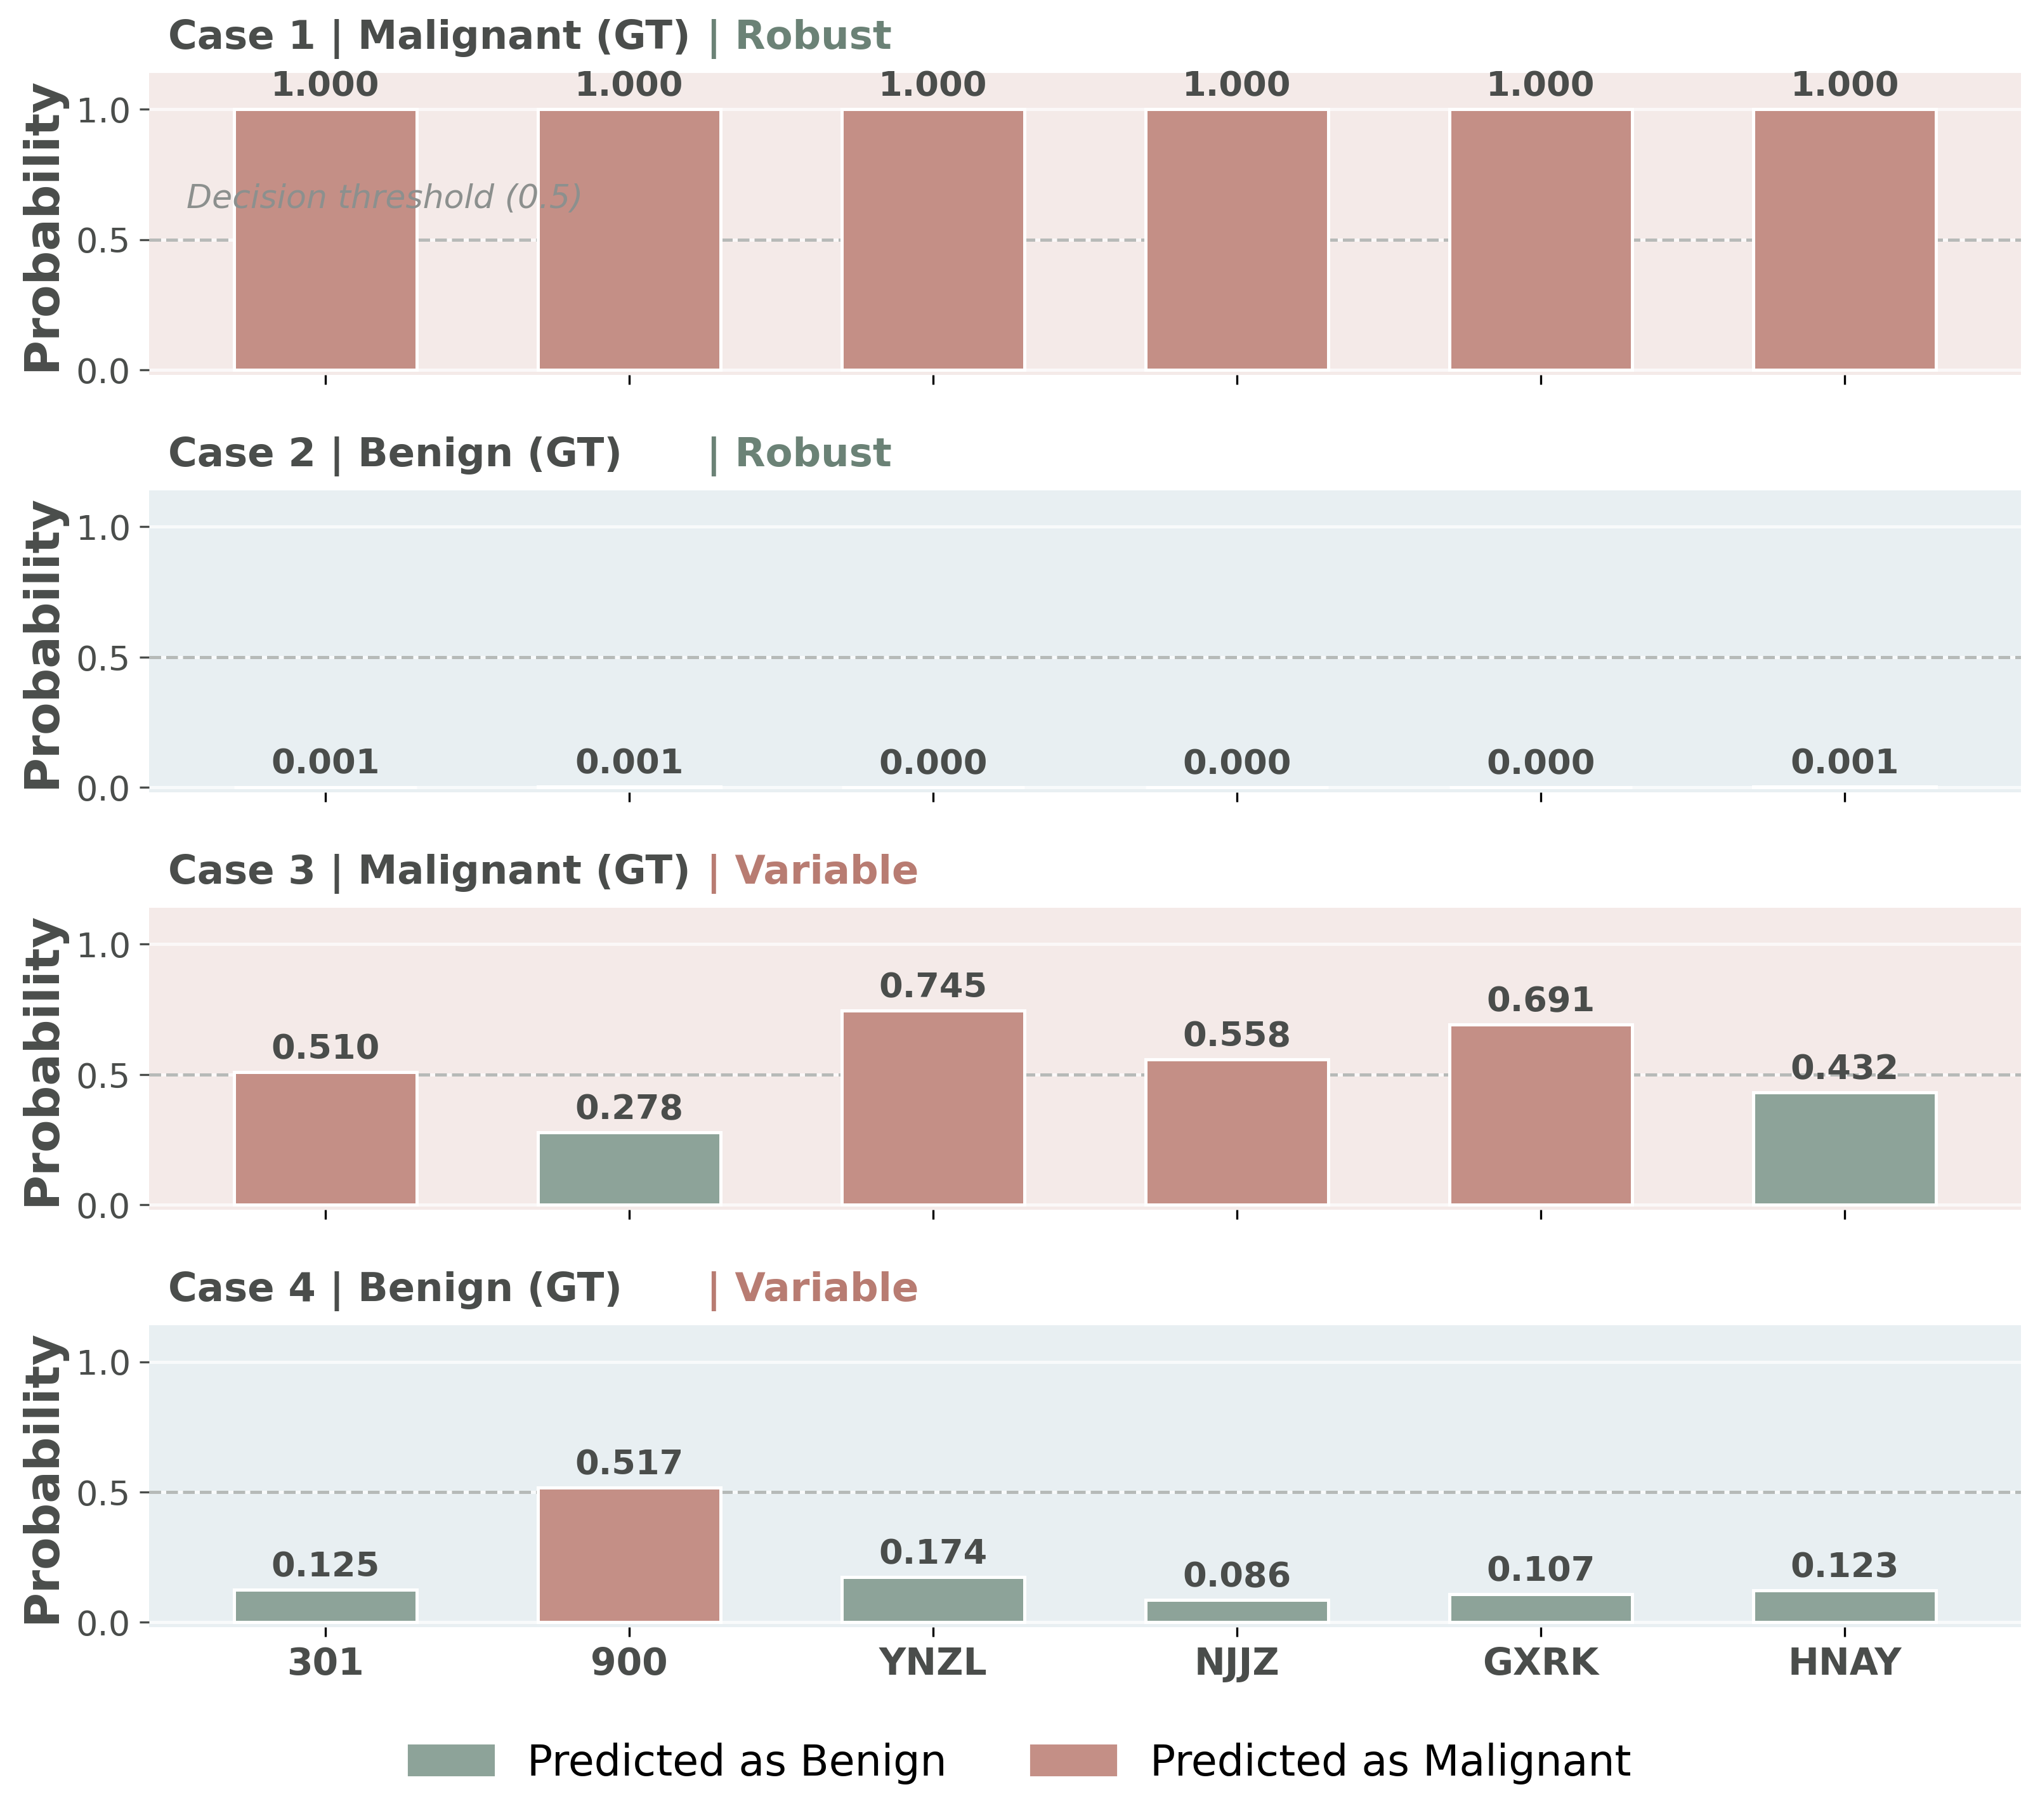

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


BASE_SIZE = 16

plt.rcParams.update({
    'font.sans-serif': ['DejaVu Sans'],
    'axes.unicode_minus': False,
    'font.size': BASE_SIZE,
    'xtick.labelsize': BASE_SIZE - 2,
    'ytick.labelsize': BASE_SIZE - 3,
})

df = pd.read_csv('Consistent/analysis_results/aligned_multicenter_results.csv')

centers = ['301', '900', 'Yunnan', 'Nanjing', 'Guangxi', 'Henan']
labels = ['301', '900', 'YNZL', 'NJJZ', 'GXRK', 'HNAY']
cols = {
    '301': ('probs_301', 'pred_301'),
    '900': ('probs_900', 'pred_900'),
    'Yunnan': ('probs_YNZL', 'pred_YNZL'),
    'Nanjing': ('probs_NJJZ', 'pred_NJJZ'),
    'Guangxi': ('probs_GXRK', 'pred_GXRK'),
    'Henan': ('probs_HNAY', 'pred_HNAY')
}

C = {
    'bg_mal': '#F4EAE8',
    'bg_ben': '#E8EFF2',
    'pred_ben': '#8DA399',
    'pred_mal': '#C48F86',
    'line': '#A6ABA8',
    'text': '#4A4D4B',
    'muted': '#8C908E',
    'robust': '#6B8276',
    'hard': '#B87C72'
}

x = np.arange(len(centers)) * 0.7
preds = np.vstack([df[cols[c][1]].values for c in centers]).T
same = np.all(preds == preds[:, [0]], axis=1)

def pick(label, robust, k=0):
    idx = df[(df['label'].eq(label)) & (same == robust)].index
    return idx[min(k, len(idx) - 1)] if len(idx) else None

case_ids = [
    pick(1, True, 1),
    pick(0, True, 0),
    pick(1, False, 0),
    pick(0, False, 0),
]
case_ids = [i for i in case_ids if i is not None]

# 根据字号动态稍微调整每张子图的高度，防止高字号时溢出
fig, axes = plt.subplots(len(case_ids), 1, figsize=(11, (2.0 + BASE_SIZE*0.03) * len(case_ids)), dpi=300, sharex=True)
axes = np.atleast_1d(axes)

for n, (ax, idx) in enumerate(zip(axes, case_ids), 1):
    row = df.loc[idx]
    true_label = int(row['label'])
    robust = same[idx]

    probs = [row[cols[c][0]] for c in centers]
    pred = [int(row[cols[c][1]]) for c in centers]
    bar_colors = [C['pred_mal'] if p else C['pred_ben'] for p in pred]

    ax.set_facecolor(C['bg_mal'] if true_label else C['bg_ben'])
    ax.bar(x, probs, color=bar_colors, edgecolor='white', linewidth=1.2, width=0.42, zorder=3)

    ax.axhline(0.5, color=C['line'], ls='--', lw=1.2, alpha=0.8, zorder=2)
    
    # 阈值文本字号动态控制
    if n == 1:
        ax.text(0.02, 0.53, 'Decision threshold (0.5)', transform=ax.transAxes, 
                fontsize=BASE_SIZE - 3.5, color=C['muted'], ha='left', va='bottom', fontstyle='italic')

    # 柱状图顶部的概率数值字号动态控制
    for i, p in enumerate(probs):
        ax.text(x[i], min(p + 0.025, 1.08), f'{p:.3f}', ha='center', va='bottom', 
                fontsize=BASE_SIZE - 3, fontweight='semibold', color=C['text'])

    gt = 'Malignant' if true_label else 'Benign'
    status = 'Robust' if robust else 'Variable'
    status_color = C['robust'] if robust else C['hard']

    # 顶部 Case 标题字号动态控制
    ax.text(0.01, 1.08, f'Case {n} | {gt} (GT)', transform=ax.transAxes, 
            fontsize=BASE_SIZE - 1, fontweight='bold', color=C['text'], ha='left')
    
    # 根据字号大小，动态计算第二个标签的横向偏移量，防止重叠
    status_offset = 0.25 + (BASE_SIZE * 0.003)
    ax.text(status_offset, 1.08, f'| {status}', transform=ax.transAxes, 
            fontsize=BASE_SIZE - 1, fontweight='bold', color=status_color, ha='left')

    ax.set_ylim(-0.02, 1.14)
    ax.set_yticks([0, 0.5, 1.0])
    
    # Y轴概率标签字号
    ax.set_ylabel('Probability', fontsize=BASE_SIZE + 2, color=C['text'], fontweight='semibold')
    ax.tick_params(axis='y', colors=C['text']) # 移除了写死的 labelsize，交由 rcParams 全局接管
    ax.grid(axis='y', color='white', lw=1.2, alpha=0.7, zorder=1)

    for s in ax.spines.values():
        s.set_visible(False)

# X轴中心标签字号
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels, fontsize=BASE_SIZE - 2, fontweight='semibold', color=C['text'])

# 底部图例字号
legend = [
    mpatches.Patch(color=C['pred_ben'], label='Predicted as Benign'),
    mpatches.Patch(color=C['pred_mal'], label='Predicted as Malignant')
]
fig.legend(handles=legend, loc='lower center', ncol=2, frameon=False, 
           fontsize=BASE_SIZE, bbox_to_anchor=(0.5, -0.01))

os.makedirs('centers', exist_ok=True)
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.savefig('centers/cases_consistency.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()